# Pixel Canvas 🎨

Rysowanie przez przypisywanie kolorów do pikseli.

Możesz:
- Ustawić kolor dowolnego piksela
- Wyczyścić płótno
- Odświeżać obraz w pętli, żeby robić animacje

To jest szkielet, który można rozbudować np. do Game of Life!

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time

## Klasa PixelCanvas

Główna klasa do rysowania pikseli.

In [2]:
class PixelCanvas:
    """Płótno pikselowe - rysuj przypisując kolory do pikseli."""

    def __init__(self, width: int = 20, height: int = 20, pixel_size: float = 0.4):
        """Stwórz nowe płótno.

        Args:
            width: szerokość w pikselach
            height: wysokość w pikselach
            pixel_size: wielkość każdego piksela na ekranie (w calach)
        """
        self.width = width
        self.height = height
        self.pixel_size = pixel_size
        # Tablica kolorów: każdy piksel to [R, G, B] od 0.0 do 1.0
        self.pixels = np.zeros((height, width, 3), dtype=np.float64)

    def set_pixel(self, x: int, y: int, color: tuple[float, float, float]):
        """Ustaw kolor piksela.

        Args:
            x: pozycja w poziomie (0 = lewo)
            y: pozycja w pionie (0 = góra)
            color: kolor jako (R, G, B), każda wartość od 0.0 do 1.0
        """
        if 0 <= x < self.width and 0 <= y < self.height:
            self.pixels[y, x] = color

    def get_pixel(self, x: int, y: int) -> tuple[float, float, float]:
        """Pobierz kolor piksela."""
        if 0 <= x < self.width and 0 <= y < self.height:
            r, g, b = self.pixels[y, x]
            return (r, g, b)
        return (0.0, 0.0, 0.0)

    def clear(self, color: tuple[float, float, float] = (0.0, 0.0, 0.0)):
        """Wyczyść płótno (domyślnie na czarno)."""
        self.pixels[:, :] = color

    def fill_rect(self, x: int, y: int, w: int, h: int, color: tuple[float, float, float]):
        """Wypełnij prostokąt kolorem."""
        x1 = max(0, x)
        y1 = max(0, y)
        x2 = min(self.width, x + w)
        y2 = min(self.height, y + h)
        self.pixels[y1:y2, x1:x2] = color

    def show(self):
        """Pokaż płótno."""
        fig_w = self.width * self.pixel_size
        fig_h = self.height * self.pixel_size
        fig, ax = plt.subplots(figsize=(fig_w, fig_h))
        ax.imshow(self.pixels, interpolation='nearest')
        ax.set_xticks(range(self.width))
        ax.set_yticks(range(self.height))
        ax.grid(True, color='gray', linewidth=0.5, alpha=0.3)
        ax.tick_params(labelsize=6)
        plt.tight_layout()
        plt.show()

    def show_update(self, fig, ax, img):
        """Zaktualizuj istniejący obraz (do animacji)."""
        img.set_data(self.pixels.copy())
        fig.canvas.draw_idle()
        fig.canvas.flush_events()

    def create_figure(self):
        """Stwórz figurę do animacji. Zwraca (fig, ax, img)."""
        fig_w = self.width * self.pixel_size
        fig_h = self.height * self.pixel_size
        fig, ax = plt.subplots(figsize=(fig_w, fig_h))
        img = ax.imshow(self.pixels, interpolation='nearest')
        ax.set_xticks(range(self.width))
        ax.set_yticks(range(self.height))
        ax.grid(True, color='gray', linewidth=0.5, alpha=0.3)
        ax.tick_params(labelsize=6)
        plt.tight_layout()
        return fig, ax, img

## Predefiniowane kolory

Kilka kolorów do łatwego użycia.

In [3]:
# Kolory jako (R, G, B) - wartości od 0.0 do 1.0
BLACK   = (0.0, 0.0, 0.0)
WHITE   = (1.0, 1.0, 1.0)
RED     = (1.0, 0.0, 0.0)
GREEN   = (0.0, 1.0, 0.0)
BLUE    = (0.0, 0.0, 1.0)
YELLOW  = (1.0, 1.0, 0.0)
CYAN    = (0.0, 1.0, 1.0)
MAGENTA = (1.0, 0.0, 1.0)
ORANGE  = (1.0, 0.5, 0.0)
GRAY    = (0.5, 0.5, 0.5)

## Przykład 1: Rysowanie pojedynczych pikseli

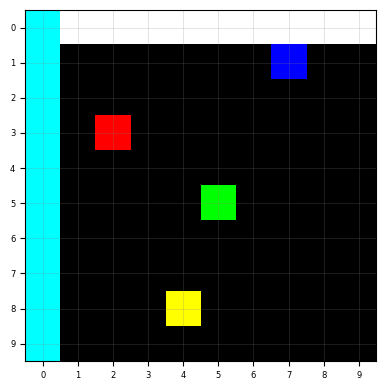

In [4]:
canvas = PixelCanvas(10, 10)

# Narysuj kilka pikseli
canvas.set_pixel(2, 3, RED)
canvas.set_pixel(5, 5, GREEN)
canvas.set_pixel(7, 1, BLUE)
canvas.set_pixel(4, 8, YELLOW)

# Narysuj linię poziomą
for x in range(10):
    canvas.set_pixel(x, 0, WHITE)

# Narysuj linię pionową
for y in range(10):
    canvas.set_pixel(0, y, CYAN)

canvas.show()

## Przykład 2: Wzory i kształty

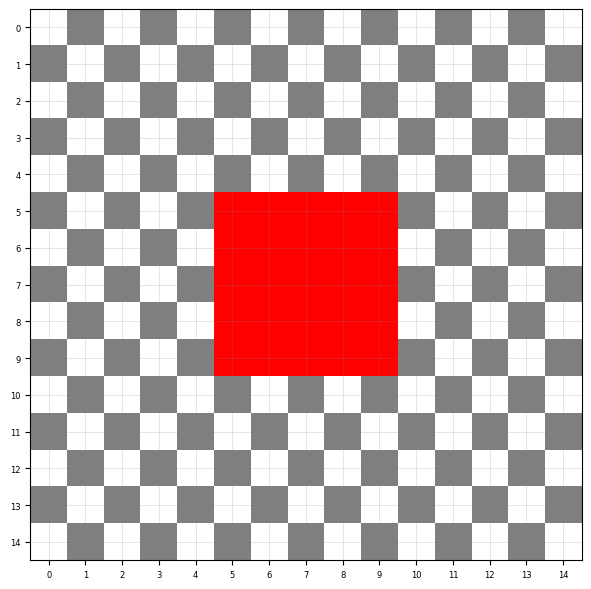

In [5]:
canvas = PixelCanvas(15, 15)

# Szachownica
for y in range(15):
    for x in range(15):
        if (x + y) % 2 == 0:
            canvas.set_pixel(x, y, WHITE)
        else:
            canvas.set_pixel(x, y, GRAY)

# Czerwony kwadrat na środku
canvas.fill_rect(5, 5, 5, 5, RED)

canvas.show()

## Przykład 3: Animacja z clear_output

Piksel porusza się po ekranie. Użyj `clear_output` do odświeżania.

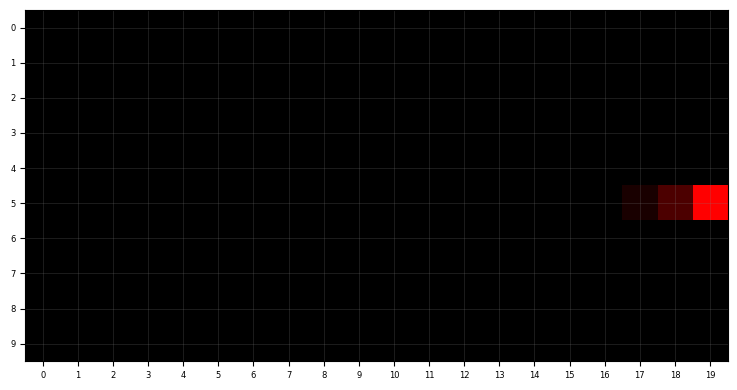

In [6]:
canvas = PixelCanvas(20, 10)

for frame in range(20):
    canvas.clear(BLACK)

    # Poruszający się piksel
    canvas.set_pixel(frame, 5, RED)

    # Ślad za pikselem
    if frame > 0:
        canvas.set_pixel(frame - 1, 5, (0.3, 0.0, 0.0))
    if frame > 1:
        canvas.set_pixel(frame - 2, 5, (0.1, 0.0, 0.0))

    clear_output(wait=True)
    canvas.show()
    time.sleep(0.2)

## Przykład 4: Animacja z odświeżaniem figury (płynniejsza)

Używa `create_figure` + `show_update` - szybsze niż clear_output.

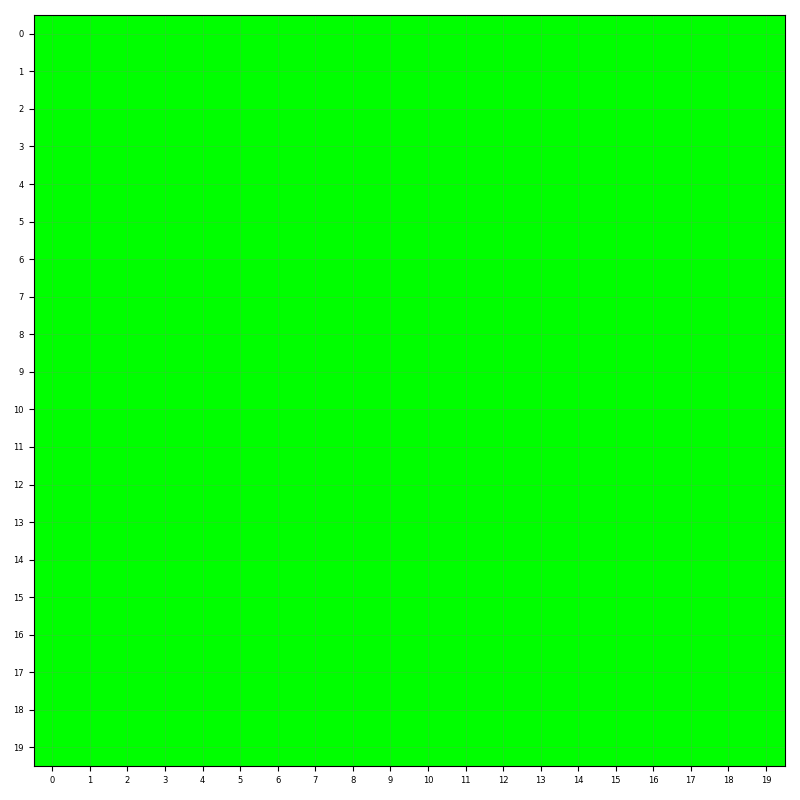

In [10]:
%matplotlib widget

canvas = PixelCanvas(20, 20)
fig, ax, img = canvas.create_figure()

# Rosnący kwadrat
for size in range(1, 11):
    canvas.clear(BLACK)
    x = 10 - size
    y = 10 - size
    canvas.fill_rect(x, y, size * 2, size * 2, GREEN)
    canvas.show_update(fig, ax, img)
    time.sleep(0.3)

## Twoja kolej! 🎮

Użyj komórek poniżej żeby rysować.

Podstawowe funkcje:
```python
canvas = PixelCanvas(szerokość, wysokość)  # stwórz płótno
canvas.set_pixel(x, y, kolor)              # ustaw piksel
canvas.get_pixel(x, y)                     # pobierz kolor
canvas.fill_rect(x, y, w, h, kolor)        # wypełnij prostokąt
canvas.clear()                             # wyczyść (czarny)
canvas.clear(WHITE)                        # wyczyść (biały)
canvas.show()                              # pokaż
```

Animacja:
```python
for frame in range(N):
    canvas.clear()
    # ... rysuj ...
    clear_output(wait=True)
    canvas.show()
    time.sleep(0.1)
```

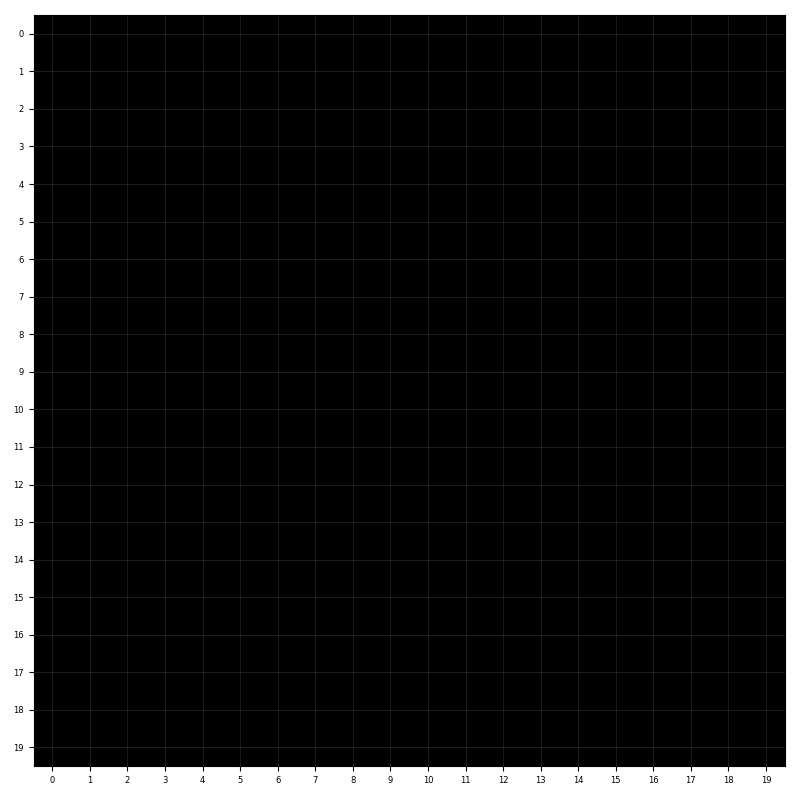

In [8]:
# Twój kod tutaj!
canvas = PixelCanvas(20, 20)

canvas.show()